In [1]:
import os, time, tarfile, urllib.request
import math, json, glob
from datetime import datetime
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 장치: {device}")
if device.type == 'cuda':
    print(f"   {torch.cuda.get_device_name(0)}\n")

# ---- CIFAR-10 다운로드 및 압축 해제 ----
cifar_tgz = '/kaggle/working/cifar10.tgz'
cifar_dir = '/kaggle/working/cifar10'
if not os.path.exists(cifar_dir):
    if not os.path.exists(cifar_tgz):
        print("⬇️ CIFAR-10 다운로드 중...")
        urllib.request.urlretrieve(
            'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz', cifar_tgz)
    print("📦 압축 해제 중...")
    with tarfile.open(cifar_tgz, 'r:gz') as tar:
        tar.extractall(path='/kaggle/working/')
print(f"📂 CIFAR-10: {cifar_dir}\n")

# ---- Dataset / DataLoader ----
IMG_SIZE = 64  # ViT 입력 해상도
C10_MEAN, C10_STD = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)

def make_transforms(mean, std, train, strong_aug):
    if not train:
        return transforms.Compose([
            transforms.Resize(IMG_SIZE) if IMG_SIZE != 64 else transforms.Lambda(lambda x: x),
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(), transforms.Normalize(mean, std)])
    ops = [transforms.Resize((IMG_SIZE, IMG_SIZE)),
           transforms.RandomCrop(IMG_SIZE, padding=IMG_SIZE // 8),
           transforms.RandomHorizontalFlip()]
    if strong_aug:
        ops.append(transforms.RandAugment(num_ops=2, magnitude=9))
    ops += [transforms.ToTensor(), transforms.Normalize(mean, std)]
    return transforms.Compose(ops)

BATCH_SIZE = 256
NUM_WORKERS = 2

c10_train = datasets.ImageFolder(os.path.join(cifar_dir, 'train'),
                                 transform=make_transforms(C10_MEAN, C10_STD, True, False)) # 스크래치 학습 시 strong_aug=False 유지 (기존 설정 반영)
c10_test = datasets.ImageFolder(os.path.join(cifar_dir, 'test'),
                                transform=make_transforms(C10_MEAN, C10_STD, False, False))
c10_train_loader = DataLoader(c10_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
c10_test_loader = DataLoader(c10_test, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

print(f"CIFAR-10      : train {len(c10_train):,} / test {len(c10_test):,} / 클래스 {len(c10_train.classes)}")
print(f"입력 해상도   : {IMG_SIZE}×{IMG_SIZE}\n")

🖥️ 장치: cuda
   Tesla T4

⬇️ CIFAR-10 다운로드 중...
📦 압축 해제 중...


/tmp/ipykernel_58/70002868.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/kaggle/working/')


📂 CIFAR-10: /kaggle/working/cifar10

CIFAR-10      : train 50,000 / test 10,000 / 클래스 10
입력 해상도   : 64×64



In [2]:
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_ch=3, dim=192):
        super().__init__()
        assert img_size % patch_size == 0
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_ch, dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)   # B, N, dim

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden), nn.GELU(), nn.Dropout(drop),
            nn.Linear(hidden, dim), nn.Dropout(drop))

    def forward(self, x):
        h = self.norm1(x)
        x = x + self.attn(h, h, h, need_weights=False)[0]
        return x + self.mlp(self.norm2(x))

class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, num_classes=200,
                 dim=192, depth=6, heads=3, mlp_ratio=4.0, drop=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, 3, dim)
        n = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, dim))
        self.pos_drop = nn.Dropout(drop)
        self.blocks = nn.ModuleList([Block(dim, heads, mlp_ratio, drop) for _ in range(depth)])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, num_classes)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init)

    def _init(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward_features(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1) + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)[:, 0]

    def forward(self, x):
        return self.head(self.forward_features(x))

VIT_CFG = dict(img_size=IMG_SIZE, patch_size=8, dim=192, depth=6, heads=3, mlp_ratio=4.0, drop=0.1)

def build_vit(num_classes):
    return ViT(num_classes=num_classes, **VIT_CFG).to(device)

print("✅ ViT 정의 완료\n")

✅ ViT 정의 완료



In [3]:
class Lion(optim.Optimizer):
    def __init__(self, params, lr=2e-4, betas=(0.9, 0.99), weight_decay=0.5):
        super().__init__(params, dict(lr=lr, betas=betas, weight_decay=weight_decay))

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        for group in self.param_groups:
            lr, wd = group['lr'], group['weight_decay']
            b1, b2 = group['betas']
            for p in group['params']:
                if p.grad is None:
                    continue
                st = self.state[p]
                if 'exp_avg' not in st:
                    st['exp_avg'] = torch.zeros_like(p)
                m, g = st['exp_avg'], p.grad
                if wd != 0:
                    p.mul_(1 - lr * wd)
                p.add_(m.mul(b1).add_(g, alpha=1 - b1).sign_(), alpha=-lr)
                m.mul_(b2).add_(g, alpha=1 - b2)
        return loss

class SAMAscent:
    def __init__(self, params, rho=0.0):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho
        self._e_w = {}

    def set_rho(self, rho):
        self.rho = rho

    @torch.no_grad()
    def ascent(self):
        if self.rho <= 0:
            return False
        grads = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        if not grads:
            return False
        gn = torch.norm(torch.stack(grads), p=2)
        if gn.item() < 1e-12:
            return False
        scale = self.rho / (gn + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None:
                continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self._e_w[p] = e_w
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self._e_w.items():
            p.sub_(e_w)
        self._e_w.clear()

print("✅ Lion + SAMAscent 정의 완료!\n")

✅ Lion + SAMAscent 정의 완료!



In [4]:
def wsd_lr(epoch, total_epochs, peak_lr, warmup_epochs, decay_epochs, decay_shape='linear', final_frac=0.0):
    stable_end = total_epochs - decay_epochs
    if epoch < warmup_epochs:
        return peak_lr * (epoch + 1) / warmup_epochs
    if epoch < stable_end:
        return peak_lr
    prog = min(1.0, max(0.0, (epoch - stable_end + 1) / decay_epochs))
    factor = 1.0 - math.sqrt(prog) if decay_shape == 'one_minus_sqrt' else 1.0 - prog
    return peak_lr * (final_frac + (1 - final_frac) * factor)

def make_probe(dataset, n=384, batch_size=128, seed=1234):
    g = torch.Generator().manual_seed(seed)
    idx = torch.randperm(len(dataset), generator=g)[:n].tolist()
    loader = DataLoader(Subset(dataset, idx), batch_size=batch_size, shuffle=False)
    return [(x.clone(), y.clone()) for x, y in loader]

def measure_sharpness(model, criterion, probe_batches, rho=0.05):
    was_training = model.training
    model.eval()
    diffs = []
    for inputs, targets in probe_batches:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()
        model.zero_grad(set_to_none=True)
        criterion(model(inputs), targets).backward()
        grads = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        scale = rho / (torch.norm(torch.stack(grads), p=2) + 1e-12)
        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w); e_ws.append((p, e_w))
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)
        model.zero_grad(set_to_none=True)
        diffs.append(loss_w_eps - loss_w)
    if was_training:
        model.train()
    return sum(diffs) / len(diffs)

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            _, pred = model(inputs).max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
    return 100. * correct / total

def run_epochs(model, optimizer, sam, criterion, train_loader, eval_loader,
               probe_batches, epoch_range, cfg, history, sharpness_history,
               rho_fn=None, tag="RUN"):
    stable_end = cfg['total_epochs'] - cfg['decay_epochs']
    for epoch in epoch_range:
        lr_now = wsd_lr(epoch, cfg['total_epochs'], cfg['peak_lr'],
                        cfg['warmup_epochs'], cfg['decay_epochs'],
                        cfg.get('decay_shape', 'linear'), cfg.get('final_frac', 0.0))
        for g in optimizer.param_groups:
            g['lr'] = lr_now
        rho_now = rho_fn(epoch) if rho_fn is not None else 0.0
        sam.set_rho(rho_now)

        model.train()
        run_loss = run_gap = 0.0
        correct = total = n_b = 0
        t0 = time.time()

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            _, pred = outputs.max(1)
            total += targets.size(0); correct += pred.eq(targets).sum().item()

            gap = 0.0
            if sam.ascent():
                optimizer.zero_grad(set_to_none=True)
                loss_adv = criterion(model(inputs), targets)
                loss_adv.backward()
                gap = loss_adv.item() - loss.item()
                sam.restore()

            if cfg.get('grad_clip') is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()
            run_loss += loss.item(); run_gap += gap; n_b += 1

        dt = time.time() - t0
        train_loss = run_loss / n_b
        train_acc = 100. * correct / total
        eval_acc = evaluate(model, eval_loader)

        history['epoch'].append(epoch + 1)
        history['lr'].append(lr_now)
        history['rho'].append(rho_now)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(eval_acc)
        history['ascent_gap'].append(run_gap / n_b)
        history['time'].append(dt)

        sharp_str = ""
        if (epoch + 1) % cfg['sharpness_interval'] == 0 or epoch == epoch_range[-1]:
            sv = measure_sharpness(model, criterion, probe_batches)
            sharpness_history['epoch'].append(epoch + 1)
            sharpness_history['sharpness'].append(sv)
            sharp_str = f" | Sharp: {sv:.4f}"

        ph = "warmup" if epoch < cfg['warmup_epochs'] else ("stable" if epoch < stable_end else "decay ")
        print(f"[{tag}|{ph}] Ep [{epoch+1}/{cfg['total_epochs']}] | {dt:.1f}s | "
              f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Eval: {eval_acc:.2f}% | "
              f"lr: {lr_now:.2e} | rho: {rho_now:.4f}{sharp_str}")

def new_history():
    return ({k: [] for k in ['epoch','lr','rho','train_loss','train_acc','test_acc','ascent_gap','time']},
            {'epoch': [], 'sharpness': []})

SAVE_DIR = '/kaggle/working/vit_experiments'
os.makedirs(SAVE_DIR, exist_ok=True)
print("✅ WSD 스케줄 + 학습 루프 정의 완료!\n")

✅ WSD 스케줄 + 학습 루프 정의 완료!



In [5]:
# ==========================================
# [대조군 실험] Stage 1 — CIFAR-10 from scratch (warmup+stable)
# ==========================================
USE_PRETRAINED = False

FT_EPOCHS = 30
FT_DECAY_EPOCHS = 10
FT_PEAK_LR = 1e-4     
FT_WD = 0.5

FT_CFG = {
    'total_epochs': FT_EPOCHS,
    'warmup_epochs': 2,
    'decay_epochs': FT_DECAY_EPOCHS,
    'peak_lr': FT_PEAK_LR,
    'grad_clip': 1.0,
    'sharpness_interval': 2,
    'use_pretrained': USE_PRETRAINED,
}
FT_STABLE_END = FT_EPOCHS - FT_DECAY_EPOCHS

torch.manual_seed(42)
model = build_vit(num_classes=10)
print("🆕 from scratch (사전학습 미사용)")

optimizer = Lion(model.parameters(), lr=FT_PEAK_LR, weight_decay=FT_WD)
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

c10_probe = make_probe(c10_train)
history, sharpness_history = new_history()

TAG = 'scratch'
print(f"\n🚀 Stage 1 [{TAG}] — CIFAR-10 warmup+stable ({FT_STABLE_END} epochs)\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(FT_STABLE_END), FT_CFG, history, sharpness_history,
           rho_fn=None, tag=f"S1-{TAG}")

stage1_ckpt = os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt')
torch.save({'model': model.state_dict(), 'optimizer': optimizer.state_dict(),
            'cfg': FT_CFG, 'stable_end': FT_STABLE_END, 'tag': TAG,
            'history': history, 'sharpness_history': sharpness_history}, stage1_ckpt)

print(f"\n💾 체크포인트 저장: {stage1_ckpt}")
print(f"   Train {history['train_acc'][-1]:.2f}% | Test {history['test_acc'][-1]:.2f}% | "
      f"Sharp {sharpness_history['sharpness'][-1]:.4f}")

🆕 from scratch (사전학습 미사용)

🚀 Stage 1 [scratch] — CIFAR-10 warmup+stable (20 epochs)

[S1-scratch|warmup] Ep [1/30] | 32.8s | Loss: 1.9043 | Train: 33.49% | Eval: 39.08% | lr: 5.00e-05 | rho: 0.0000
[S1-scratch|warmup] Ep [2/30] | 35.6s | Loss: 1.6857 | Train: 44.76% | Eval: 49.06% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.1841
[S1-scratch|stable] Ep [3/30] | 36.3s | Loss: 1.5544 | Train: 51.03% | Eval: 52.77% | lr: 1.00e-04 | rho: 0.0000
[S1-scratch|stable] Ep [4/30] | 35.8s | Loss: 1.4748 | Train: 54.93% | Eval: 55.87% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.2128
[S1-scratch|stable] Ep [5/30] | 35.8s | Loss: 1.4080 | Train: 57.93% | Eval: 60.38% | lr: 1.00e-04 | rho: 0.0000
[S1-scratch|stable] Ep [6/30] | 35.8s | Loss: 1.3662 | Train: 59.96% | Eval: 61.23% | lr: 1.00e-04 | rho: 0.0000 | Sharp: 0.2006
[S1-scratch|stable] Ep [7/30] | 35.8s | Loss: 1.3220 | Train: 62.22% | Eval: 62.27% | lr: 1.00e-04 | rho: 0.0000
[S1-scratch|stable] Ep [8/30] | 35.8s | Loss: 1.2816 | Train: 64.07% | Eval:

In [6]:
# ==========================================
# [대조군 실험] Stage 2 — decay 구간 분기 (SAM OFF)
# ==========================================
SAM_IN_DECAY = False
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3
TAG = 'scratch'

ckpt = torch.load(os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt'),
                  map_location=device, weights_only=False)
CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']

model = build_vit(num_classes=10)
model.load_state_dict(ckpt['model'])
optimizer = Lion(model.parameters(), lr=CFG['peak_lr'], weight_decay=FT_WD)
optimizer.load_state_dict(ckpt['optimizer'])
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = f"{ckpt['tag']}_sam_off"
start_test = ckpt['history']['test_acc'][-1]
start_sharp = ckpt['sharpness_history']['sharpness'][-1]

print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점 ep{STABLE_END}: Test {start_test:.2f}%, Sharp {start_sharp:.4f})\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

best_acc = max(history['test_acc'])
best_ep = history['epoch'][history['test_acc'].index(best_acc)]
record = {
    'arm': ARM, 'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'use_pretrained': CFG['use_pretrained'], 'cfg': CFG,
    'results': {
        'decay_start_test_acc': start_test, 'decay_start_sharpness': start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc, 'best_epoch': best_ep,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history, 'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(SAVE_DIR, f'arm_{ARM}_{ts}.json'), 'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   최종 Test  : {r['final_test_acc']:.2f}% | 최고 Test : {best_acc:.2f}% (ep {best_ep})")

🚀 Stage 2 [scratch_sam_off] — decay 10 epochs (공통 출발점 ep20: Test 77.65%, Sharp 0.1602)

[S2-scratch_sam_off|decay ] Ep [21/30] | 35.8s | Loss: 0.9651 | Train: 78.93% | Eval: 77.83% | lr: 9.00e-05 | rho: 0.0000
[S2-scratch_sam_off|decay ] Ep [22/30] | 35.8s | Loss: 0.9434 | Train: 80.07% | Eval: 78.43% | lr: 8.00e-05 | rho: 0.0000 | Sharp: 0.1421
[S2-scratch_sam_off|decay ] Ep [23/30] | 35.9s | Loss: 0.9214 | Train: 81.07% | Eval: 79.04% | lr: 7.00e-05 | rho: 0.0000
[S2-scratch_sam_off|decay ] Ep [24/30] | 35.9s | Loss: 0.8938 | Train: 82.28% | Eval: 79.38% | lr: 6.00e-05 | rho: 0.0000 | Sharp: 0.1735
[S2-scratch_sam_off|decay ] Ep [25/30] | 35.8s | Loss: 0.8732 | Train: 83.20% | Eval: 80.10% | lr: 5.00e-05 | rho: 0.0000
[S2-scratch_sam_off|decay ] Ep [26/30] | 35.9s | Loss: 0.8531 | Train: 84.18% | Eval: 80.35% | lr: 4.00e-05 | rho: 0.0000 | Sharp: 0.1498
[S2-scratch_sam_off|decay ] Ep [27/30] | 35.8s | Loss: 0.8352 | Train: 84.95% | Eval: 80.72% | lr: 3.00e-05 | rho: 0.0000
[S2-scratc

In [7]:
# ==========================================
# [대조군 실험] Stage 2 — decay 구간 분기 (SAM ON)
# ==========================================
SAM_IN_DECAY = True
RHO_MAX = 0.05
RHO_RAMP_EPOCHS = 3
TAG = 'scratch'

ckpt = torch.load(os.path.join(SAVE_DIR, f'stage1_{TAG}_ep{FT_STABLE_END}.pt'),
                  map_location=device, weights_only=False)
CFG = ckpt['cfg']
STABLE_END = ckpt['stable_end']

model = build_vit(num_classes=10)
model.load_state_dict(ckpt['model'])
optimizer = Lion(model.parameters(), lr=CFG['peak_lr'], weight_decay=FT_WD)
optimizer.load_state_dict(ckpt['optimizer'])
sam = SAMAscent(model.parameters(), rho=0.0)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

history = {k: list(v) for k, v in ckpt['history'].items()}
sharpness_history = {k: list(v) for k, v in ckpt['sharpness_history'].items()}

def rho_fn(epoch):
    if not SAM_IN_DECAY:
        return 0.0
    prog = (epoch - STABLE_END + 1) / max(1, RHO_RAMP_EPOCHS)
    return RHO_MAX * min(1.0, max(0.0, prog))

ARM = f"{ckpt['tag']}_sam_on"
start_test = ckpt['history']['test_acc'][-1]
start_sharp = ckpt['sharpness_history']['sharpness'][-1]

print(f"🚀 Stage 2 [{ARM}] — decay {CFG['decay_epochs']} epochs "
      f"(공통 출발점 ep{STABLE_END}: Test {start_test:.2f}%, Sharp {start_sharp:.4f})\n")
run_epochs(model, optimizer, sam, criterion, c10_train_loader, c10_test_loader,
           c10_probe, range(STABLE_END, CFG['total_epochs']), CFG,
           history, sharpness_history, rho_fn=rho_fn, tag=f"S2-{ARM}")

best_acc = max(history['test_acc'])
best_ep = history['epoch'][history['test_acc'].index(best_acc)]
record = {
    'arm': ARM, 'sam_in_decay': SAM_IN_DECAY,
    'rho_max': RHO_MAX if SAM_IN_DECAY else 0.0,
    'use_pretrained': CFG['use_pretrained'], 'cfg': CFG,
    'results': {
        'decay_start_test_acc': start_test, 'decay_start_sharpness': start_sharp,
        'final_train_acc': history['train_acc'][-1],
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc, 'best_epoch': best_ep,
        'final_gap': history['train_acc'][-1] - history['test_acc'][-1],
        'final_sharpness': sharpness_history['sharpness'][-1],
        'decay_time_min': sum(history['time'][STABLE_END:]) / 60,
    },
    'history': history, 'sharpness_history': sharpness_history,
}
ts = datetime.now().strftime('%Y%m%d_%H%M%S')
with open(os.path.join(SAVE_DIR, f'arm_{ARM}_{ts}.json'), 'w', encoding='utf-8') as f:
    json.dump(record, f, ensure_ascii=False, indent=2)

r = record['results']
print(f"\n🎉 [{ARM}] 완료")
print(f"   최종 Test  : {r['final_test_acc']:.2f}% | 최고 Test : {best_acc:.2f}% (ep {best_ep})")

🚀 Stage 2 [scratch_sam_on] — decay 10 epochs (공통 출발점 ep20: Test 77.65%, Sharp 0.1602)

[S2-scratch_sam_on|decay ] Ep [21/30] | 71.4s | Loss: 0.9636 | Train: 79.10% | Eval: 77.19% | lr: 9.00e-05 | rho: 0.0167
[S2-scratch_sam_on|decay ] Ep [22/30] | 71.4s | Loss: 0.9402 | Train: 80.14% | Eval: 78.84% | lr: 8.00e-05 | rho: 0.0333 | Sharp: 0.1260
[S2-scratch_sam_on|decay ] Ep [23/30] | 71.4s | Loss: 0.9187 | Train: 81.10% | Eval: 78.75% | lr: 7.00e-05 | rho: 0.0500
[S2-scratch_sam_on|decay ] Ep [24/30] | 71.4s | Loss: 0.8996 | Train: 82.10% | Eval: 79.13% | lr: 6.00e-05 | rho: 0.0500 | Sharp: 0.1076
[S2-scratch_sam_on|decay ] Ep [25/30] | 71.4s | Loss: 0.8748 | Train: 83.33% | Eval: 80.44% | lr: 5.00e-05 | rho: 0.0500
[S2-scratch_sam_on|decay ] Ep [26/30] | 71.4s | Loss: 0.8565 | Train: 84.22% | Eval: 80.38% | lr: 4.00e-05 | rho: 0.0500 | Sharp: 0.0980
[S2-scratch_sam_on|decay ] Ep [27/30] | 71.5s | Loss: 0.8376 | Train: 84.92% | Eval: 80.60% | lr: 3.00e-05 | rho: 0.0500
[S2-scratch_sam_on

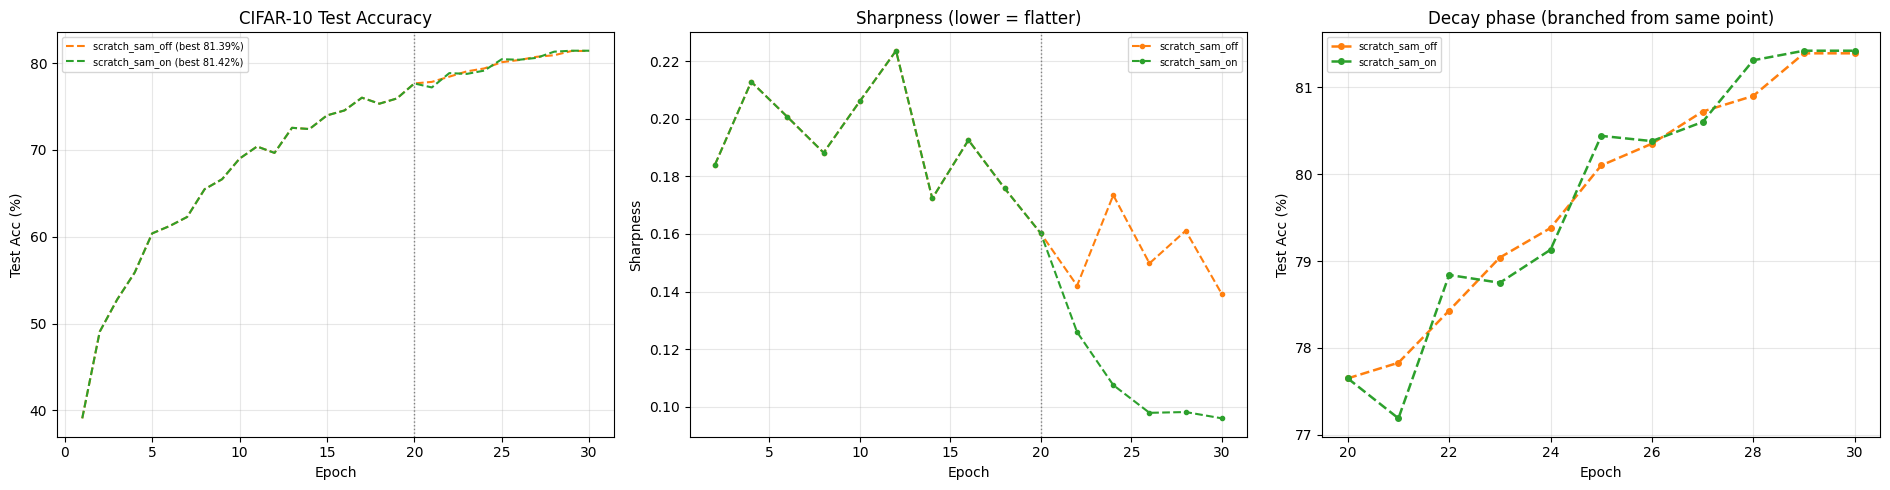

arm                          출발       최종       Δ    Train     Sharp      분
----------------------------------------------------------------------------
scratch_sam_off          77.65%   81.39%  +3.74p   87.45%    0.1391    6.0
scratch_sam_on           77.65%   81.42%  +3.77p   86.91%    0.0960   11.9
----------------------------------------------------------------------------


In [8]:
# ==========================================
# 결과 비교 및 시각화
# ==========================================
arms = {}
for fp in sorted(glob.glob(os.path.join(SAVE_DIR, 'arm_*.json'))):
    with open(fp, encoding='utf-8') as f:
        rec = json.load(f)
    arms[rec['arm']] = rec

if not arms:
    print("⚠️ 결과가 없습니다.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))
    palette = {'sam_on': 'tab:green', 'sam_off': 'tab:orange'}
    colors = {k: palette['sam_on'] if 'sam_on' in k else palette['sam_off'] for k in arms}
    styles = {k: '-' if k.startswith('pre') else '--' for k in arms}
    stable_end = list(arms.values())[0]['cfg']['total_epochs'] - \
                 list(arms.values())[0]['cfg']['decay_epochs']

    ax = axes[0]
    for k, rec in arms.items():
        ax.plot(rec['history']['epoch'], rec['history']['test_acc'],
                label=f"{k} (best {rec['results']['best_test_acc']:.2f}%)",
                color=colors[k], linestyle=styles[k], linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)')
    ax.set_title('CIFAR-10 Test Accuracy')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[1]
    for k, rec in arms.items():
        ax.plot(rec['sharpness_history']['epoch'], rec['sharpness_history']['sharpness'],
                label=k, color=colors[k], linestyle=styles[k], marker='o',
                markersize=3, linewidth=1.5)
    ax.axvline(stable_end, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness')
    ax.set_title('Sharpness (lower = flatter)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    ax = axes[2]
    for k, rec in arms.items():
        ep = rec['history']['epoch'][stable_end-1:]
        ta = rec['history']['test_acc'][stable_end-1:]
        ax.plot(ep, ta, label=k, color=colors[k], linestyle=styles[k],
                marker='o', markersize=4, linewidth=1.8)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)')
    ax.set_title('Decay phase (branched from same point)')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/kaggle/working/vit_branch_comparison_scratch.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"{'arm':<22}{'출발':>9}{'최종':>9}{'Δ':>8}{'Train':>9}{'Sharp':>10}{'분':>7}")
    print("-" * 76)
    for k, rec in arms.items():
        r = rec['results']
        d = r['final_test_acc'] - r['decay_start_test_acc']
        print(f"{k:<22}{r['decay_start_test_acc']:>8.2f}%{r['final_test_acc']:>8.2f}%"
              f"{d:>+7.2f}p{r['final_train_acc']:>8.2f}%{r['final_sharpness']:>10.4f}"
              f"{r['decay_time_min']:>7.1f}")
    print("-" * 76)